![image info](https://raw.githubusercontent.com/albahnsen/MIAD_ML_and_NLP/main/images/banner_1.png)

# Taller: Redes Neuronales

En este taller podrán poner en práctica sus conocimientos sobre la construcción e implementación de redes neuronales de una capa y multicapa. El taller está constituido por 4 puntos, en los cuales deberan seguir las intrucciones de cada numeral para su desarrollo.

## Datos predicción probabilidad de admisión a la universidad

En este taller se usará el conjunto de datos de admisiones a una universidad proveniente de la base de datos de Kaggle. Cada observación contiene la probabilidad de que un estudiante sea admitido por la universidad, dadas distintas variables predictoras como el puntaje del examén TOEFL y GRE, el promedio (GPA), entre otras. El objetivo es predecir la probabilidad de admissión de cada estudiante. Para más detalles pueden visitar el siguiente enlace: [datos](https://www.kaggle.com/mohansacharya/graduate-admissions).

In [2]:
import warnings
warnings.filterwarnings('ignore')

In [3]:
# Importación librerías
import numpy as np
import keras
import pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline

from sklearn.model_selection import train_test_split
from keras import initializers
from keras import optimizers
from keras.models import Sequential
from keras.layers import Dense
from keras.layers import Dropout

In [4]:
# Carga de datos de archivo .csv
data = pd.read_csv('https://raw.githubusercontent.com/albahnsen/MIAD_ML_and_NLP/main/datasets/universityGraduateAdmissions.csv', index_col=0)
data.head()

,GRE Score,TOEFL Score,University Rating,SOP,LOR,CGPA,Research,Chance of Admit
Serial No.,,,,,,,,
1,337,118,4,4.5,4.5,9.65,1,0.92
2,324,107,4,4.0,4.5,8.87,1,0.76
3,316,104,3,3.0,3.5,8.00,1,0.72
4,322,110,3,3.5,2.5,8.67,1,0.80
5,314,103,2,2.0,3.0,8.21,0,0.65


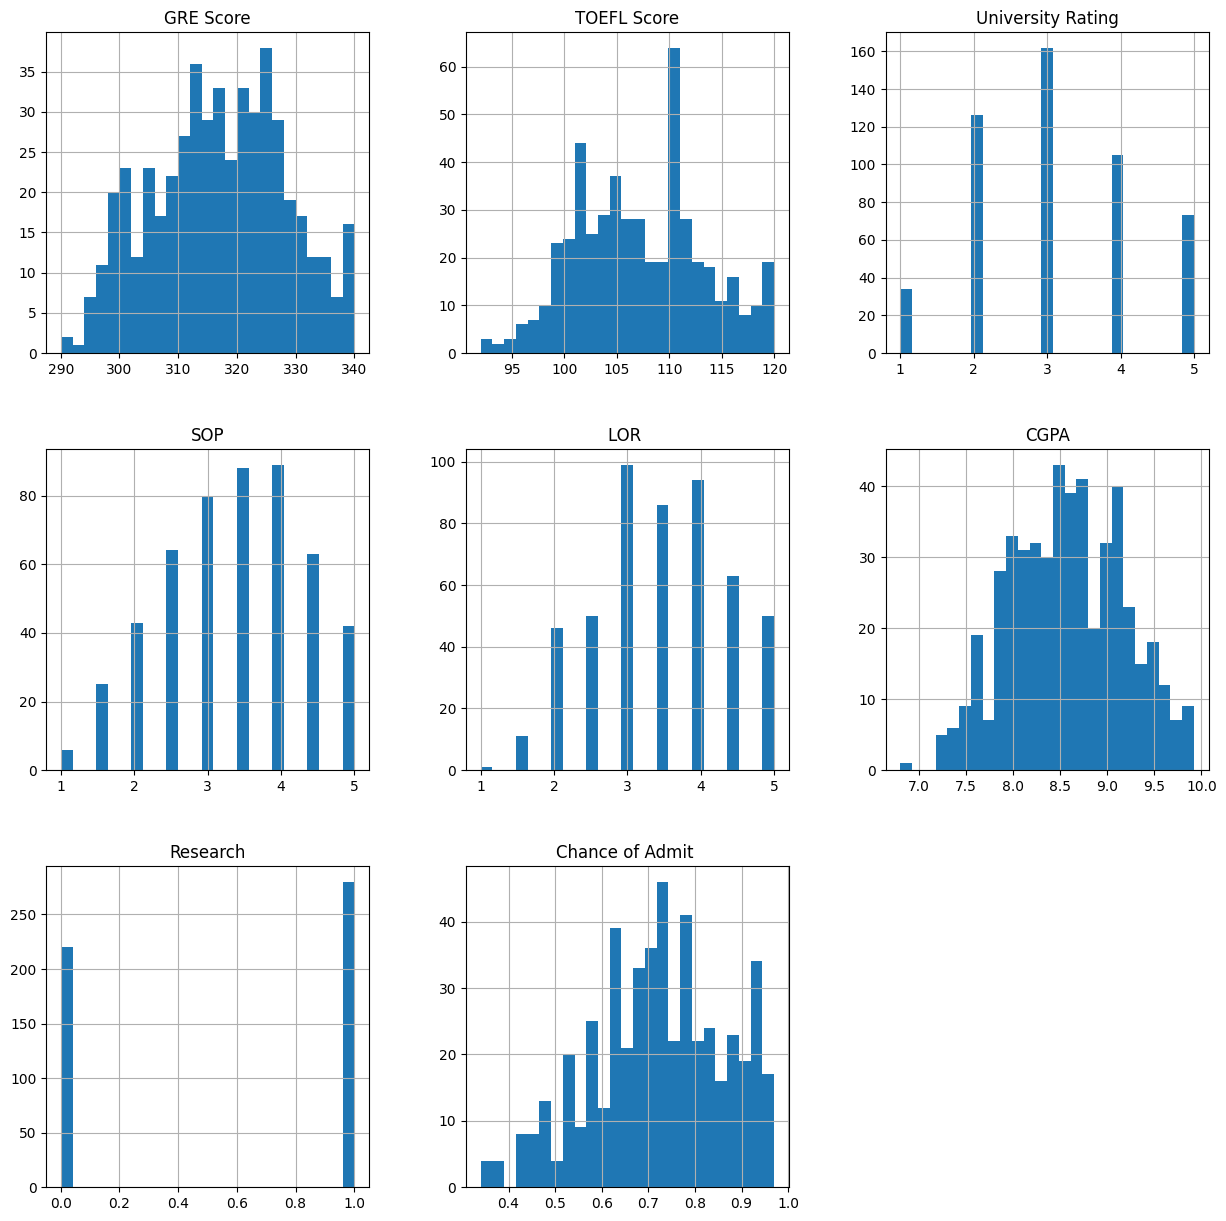

In [5]:
# Hitogramas de las varaibles del dataset
data.hist(bins=25, figsize=(15,15))
plt.show()

In [6]:
# Definición de variables predictoras (X)
X = data.drop(data.columns[-1], axis=1)
# Definición de variable de interés (y)
Y = data[data.columns[-1]]

In [7]:
# Separación de variables predictoras (X) y variable de interés (y) en set de entrenamiento y test usandola función train_test_split
xTrain, xTest, yTrain, yTest = train_test_split(X,Y,test_size=0.3, random_state=22)

### Estandarización

In [15]:
# Normalización de variables predictoras (X) con la función StandardScaler
from sklearn.preprocessing import StandardScaler

# Definición de la función StandardScaler
scaler = StandardScaler()

# Transformación de los set de entrenamiento y test
xTrain = scaler.fit_transform(xTrain)
xTest = scaler.transform(xTest)

xTrain = np.array(xTrain)
xTest = np.array(xTest)

yTrain = np.array(yTrain)
yTest = np.array(yTest)

# Definición de dimensiones de salida, varaibles de interés
output_var = 1
print(output_var, ' output variables')

# Definición de dimensiones de entrada, varaibles predictoras
dims = xTrain.shape[1]
print(dims, 'input variables')

1  output variables
7 input variables


## Punto 1 - Red Neuronal de una capa

En la celda 1 creen una **red neuronal de una capa** con la librería Keras, que prediga la probabilidad de admisión de los estudiantes, usando los sets de entrenamiento y test definidos anteriormente. Pueden usar la función de perdida, el optimizador y el número de épocas que consideren pertinentes para el modelo, justificando su selección. Finalmente, grafiquen la pérdida del modelo vs el número de épocas en el set de entrenamiento y validación, y presenten el desempeño del modelo con las métricas error absoluto medio (MAE) y error cuadrático medio (MSE).

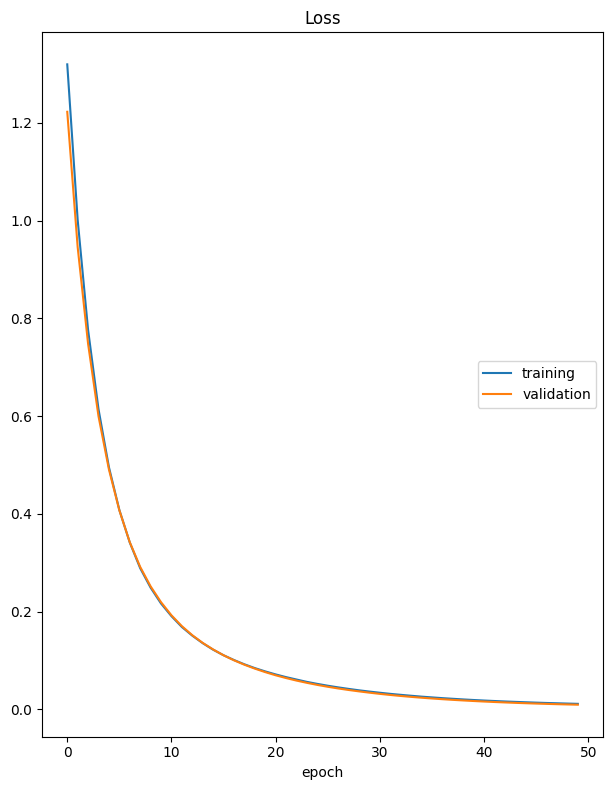

Loss
	training         	 (min:    0.011, max:    1.320, cur:    0.011)
	validation       	 (min:    0.010, max:    1.223, cur:    0.010)
11/11 ━━━━━━━━━━━━━━━━━━━━ 1s 48ms/step - loss: 0.0113 - val_loss: 0.0095
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step
MAE NN 1 capa: 0.07785429984728497
MSE NN 1 capa: 0.009536930360395605


In [23]:
# Celda 1

# Importación librerías
from livelossplot import PlotLossesKeras
from keras import backend as K
from sklearn.metrics import mean_absolute_error, mean_squared_error

K.clear_session()

# Definición red neuronal con la función Sequential()
model = Sequential()
# Definición de la capa densa con un tamaño de salida igual a output_var y un input_shape de dims
model.add(Dense(output_var, input_shape=(dims,)))

# Definición de función de perdida. Se usa mean_squared_error dado que es un ejercicio de regresión
model.compile(optimizer='sgd', loss='mean_squared_error')

# Impresión de la arquitectura de la red neuronal
print(model.summary())

# Entrenamiento de la red neuronal con 50 épocas
NN_1 = model.fit(xTrain, yTrain,
          verbose=1,
          epochs=50,
          batch_size=32,
          validation_data=(xTest, yTest),
          callbacks=[PlotLossesKeras()])

yPred = model.predict(xTest)

# Métricas
mae_1 = mean_absolute_error(yTest, yPred)
mse_1 = mean_squared_error(yTest, yPred)

print("MAE NN 1 capa:", mae_1)
print("MSE NN 1 capa:", mse_1)

* Función de pérdida: Dado que el objetivo es un valor continuo (0 a 1), se selecciona MSE (Mean Squared Error). Al elevar el error al cuadrado, se penalizan más fuerte los errores grandes, obligando al modelo a priorizar la reducción de errores significativos.

* Optimizador: Se utiliza SGD (Stochastic Gradient Descent) para mantener simplicidad y un control directo sobre el learning rate. Esto facilita entender cómo está convergiendo el modelo y evita la sobrecarga computacional de otros algoritmos.

* Número de épocas: Se establece en 50 debido a que en problemas de regresión sencillos (con pocas variables), las redes neuronales suelen converger rápido. Este valor equilibra el tiempo de cómputo con la necesidad de que el modelo reconozca los patrones de las variables, evitando así el overfitting.

* Batch size: Un batch size pequeño de 32 permite introducir variabilidad (ruido) que ayuda al modelo a escapar de mínimos locales y generalizar mejor la tendencia del chance de admisión, aprovechando que el número de variables no exige un consumo alto de memoria.

**Se seleccionó como función de pérdida el error cuadrático medio (MSE) debido a que penaliza con mayor fuerza los errores grandes y es una de las métricas más utilizadas en problemas de regresión. Como optimizador se utilizó SGD (Stochastic Gradient Descent), el cual ajusta iterativamente los pesos de la red mediante descenso del gradiente. El modelo fue entrenado durante 50 épocas con un batch size de 32, buscando un equilibrio entre tiempo de entrenamiento y capacidad de aprendizaje.**

La red neuronal de una sola capa logró aprender adecuadamente la relación entre las variables predictoras y la probabilidad de admisión de los estudiantes.

La gráfica de pérdida muestra una disminución progresiva tanto en entrenamiento como en validación, evidenciando que el modelo converge correctamente durante las épocas de entrenamiento. Además, las curvas presentan comportamientos similares, lo que indica que no existe un sobreajuste significativo.

El modelo obtuvo un MAE de 0.0778 y un MSE de 0.0095, valores que reflejan un buen desempeño predictivo considerando la simplicidad de la arquitectura implementada.

Sin embargo, al tratarse de una red neuronal de una sola capa, la capacidad del modelo para capturar relaciones no lineales complejas es limitada, por lo que redes multicapa podrían mejorar el desempeño.

## Punto 2 - Red Neuronal multicapa

En la celda 2 creen una **red neuronal con dos capas** con la librería Keras, que prediga la probabilidad de admisión de los estudiantes usando los sets de entrenamiento y test definidos anteriormente. Pueden usar la función de perdida, el optimizador, el número de épocas y el número de neuronas que consideren pertinentes para el modelo, justificando su selección. Finalmente, grafiquen la pérdida del modelo vs el número de épocas en el set de entrenamiento y validación, y presenten el desempeño del modelo con las métricas error absoluto medio (MAE) y error cuadrático medio (MSE).

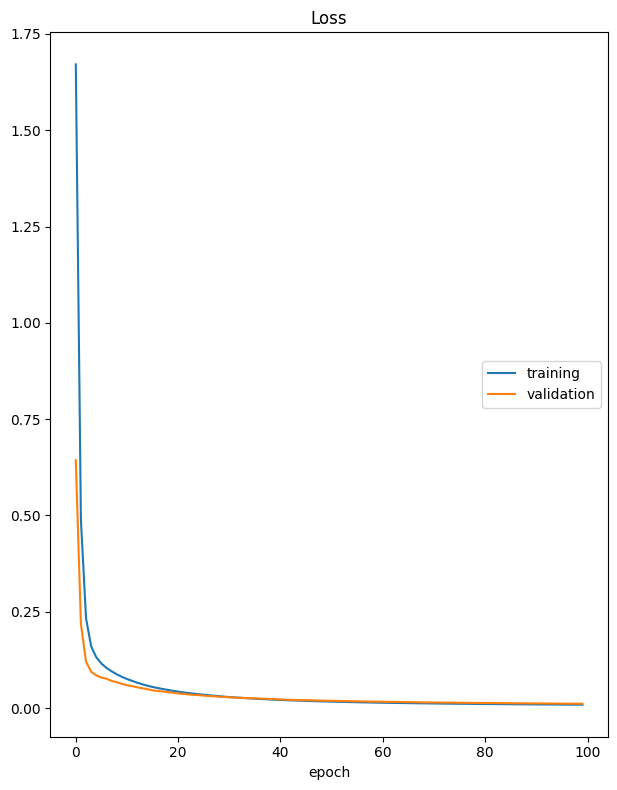

Loss
	training         	 (min:    0.009, max:    1.671, cur:    0.009)
	validation       	 (min:    0.011, max:    0.643, cur:    0.011)
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step - loss: 0.0088 - val_loss: 0.0113
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step
MAE NN 2 capas: 0.07196267832120261
MSE NN 2 capas: 0.008966747152063068


In [24]:
# Celda 2

# Importación librerías
from keras.layers import Activation

K.clear_session()

# Definición red neuronal con la función Sequential()
model = Sequential()

# Definición de la capa densa con un tamaño de salida igual a output_var y un input_shape de dims
model.add(Dense(16, input_shape=(dims,),activation='relu'))
model.add(Dense(output_var))

# Impresión de la arquitectura de la red neuronal
print(model.summary())

# Definición de función de perdida. Se usa mean_squared_error dado que es un ejercicio de regresión
model.compile(optimizer='sgd', loss='mean_squared_error')

# Separación de datos de entrenamiento para considerar un set de validación durante entrenamiento
X_train, X_val, Y_train, Y_val = train_test_split(xTrain, yTrain, test_size=0.15, random_state=42)

# Entrenamiento de la red neuronal con dos capas con 100 épocas
NN_2 = model.fit(X_train, Y_train,
          verbose=1,
          validation_data=(X_val, Y_val),
          epochs=100,
          batch_size=32,
          callbacks=[PlotLossesKeras()])

yPred = model.predict(xTest)

# Métricas
mae_2 = mean_absolute_error(yTest, yPred)
mse_2 = mean_squared_error(yTest, yPred)

print("MAE NN 2 capas:", mae_2)
print("MSE NN 2 capas:", mse_2)

Se usó la función de perdida y el optimizador del punto 1.

* Número de épocas: Debido a que la pérdida continuaba disminuyendo al finalizar las 50 épocas, se incrementó el número de épocas a 100 para permitir una mejor convergencia del modelo.

* Número de neuronas: Se seleccionó una capa oculta de 16 neuronas con el fin de proporcionar al modelo suficiente capacidad para aprender relaciones no lineales entre las variables predictoras y el chance de admisión, sin incrementar excesivamente la complejidad de la red, evitando así overfitting y manteneniendo un entrenamiento computacionalmente eficiente.

* Función de activación:  Se utiliza la función ReLU (Rectified Linear Unit) porque es eficiente computacionalmente y ayuda a evitar el Gradient Fading, permitiendo que la red aprenda relaciones no lineales entre las variables de entrada de forma rápida.

**Se utilizó una capa oculta de 16 neuronas con función de activación ReLU, permitiendo introducir no linealidades y mejorando la capacidad de representación del modelo frente a la red de una sola capa. El número de épocas se incrementó a 100 debido a que la pérdida continuaba disminuyendo después de las primeras 50 épocas (establecidas inicialmente), permitiendo una mejor convergencia usando el optimizador SGD.**

La red neuronal multicapa presentó una reducción progresiva de la pérdida tanto en entrenamiento como en validación, evidenciando un proceso de aprendizaje estable mediante gradiente descendiente y backpropagation.

El modelo obtuvo un MAE de 0.0719 y un MSE de 0.0089, mejorando ligeramente el desempeño respecto a la red neuronal de una sola capa.

Esto sugiere que la incorporación de una capa oculta permitió capturar relaciones más complejas entre las variables predictoras y el chance de admisión.

## Punto 3  - Red Neuronal multicapa

En la celda 3 creen **una red neuronal con más de una capa con la librería Keras, usando early stopping y dropout,** que prediga la probabilidad de admisión de los estudiantes con los sets de entrenamiento y test definidos anteriormente. Pueden usar la función de perdida, el optimizador, el número de épocas y el número de neuronas que consideren pertinentes para el modelo, justificando su selección. Finalmente, grafiquen la pérdida del modelo vs el número de épocas en el set de entrenamiento y validación, y presenten el desempeño del modelo con las métricas error absoluto medio (MAE) y error cuadrático medio (MSE).

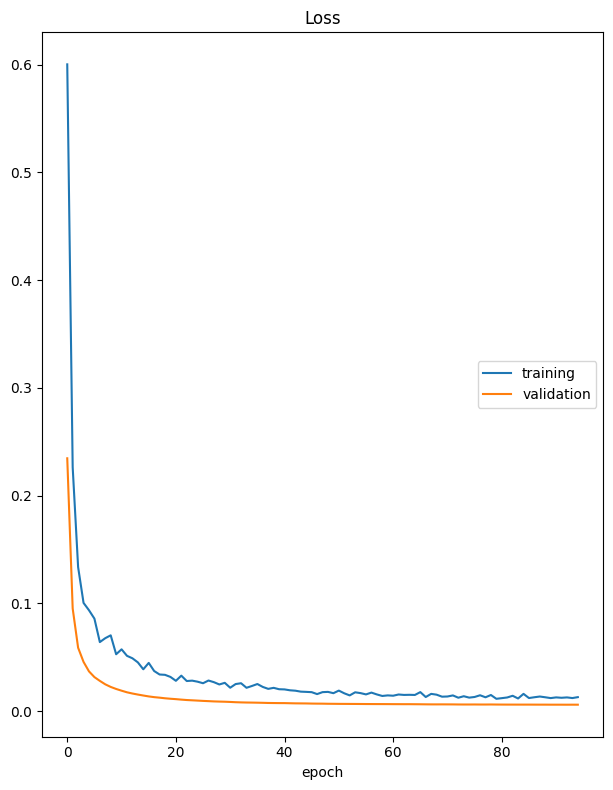

Loss
	training         	 (min:    0.012, max:    0.600, cur:    0.013)
	validation       	 (min:    0.006, max:    0.235, cur:    0.006)
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step - loss: 0.0131 - val_loss: 0.0061
Epoch 95: early stopping
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step
MAE NN multicapa con early stopping y Dropout: 0.07312138557434082
MSE NN multicapa con early stopping y Dropout: 0.008803790323180025


In [31]:
# Celda 3

# Importación librerías
from keras.callbacks import EarlyStopping, ModelCheckpoint

K.clear_session()

# Definición red neuronal con la función Sequential()
model = Sequential()

# Definición de la capa densa con un tamaño de salida igual a output_var y un input_shape de dims
model.add(Dense(16, input_shape=(dims,),activation='relu'))
model.add(Dropout(0.2)) #Apagar 20% de neuronas aleatoriamente
model.add(Dense(8,activation='relu'))
model.add(Dense(output_var))

# Impresión de la arquitectura de la red neuronal
print(model.summary())

# Definición de la función EarlyStopping para considerar durante el entrenamiento
early_stop = EarlyStopping(monitor='val_loss', patience=2, verbose=1)

# Definición de la función ModelCheckpoint para guardar el modelo con mejor desempeño
fBestModel = 'best_model.h5'
best_model = ModelCheckpoint(fBestModel, verbose=0, save_best_only=True)

# Definición de función de perdida. Se usa mean_squared_error dado que es un ejercicio de regresión
model.compile(optimizer='sgd', loss='mean_squared_error')

# Separación de datos de entrenamiento para considerar un set de validación durante entrenamiento
X_train, X_val, Y_train, Y_val = train_test_split(xTrain, yTrain, test_size=0.15, random_state=42)

# Entrenamiento de la red neuronal con dos capas con 100 épocas
NN_3 = model.fit(X_train, Y_train,
          verbose=True,
          validation_data=(X_val, Y_val),
          epochs=100,
          batch_size=32,
          callbacks=[best_model, early_stop, PlotLossesKeras()])

yPred = model.predict(xTest)

# Métricas
mae_3 = mean_absolute_error(yTest, yPred)
mse_3 = mean_squared_error(yTest, yPred)

print("MAE NN multicapa con early stopping y Dropout:", mae_3)
print("MSE NN multicapa con early stopping y Dropout:", mse_3)

Se usó la función de perdida, el optimizador y el número de épocas del punto 2.

* Número de neuronas: Se definen dos capas ocultas siguiendo una estructura decreciente de 16 y 8 neuronas. Esto permite que la primera capa capture una combinación amplia de las variables de entrada, mientras que la segunda compila esa información en los puntos más relevantes. De esta manera, el modelo no se pierde en los detalles y puede dar una predicción del chance de admisión mucho más acertada y simplificada

* Dropout: Se optó por una tasa de 0.2 para desactivar aleatoriamente parte de las neuronas durante el entrenamiento, buscando reducir el riesgo de sobreajuste y mejorar la capacidad de generalización del modelo.

* Early stopping: Se estableció para monitorear la pérdida en validación para detener automáticamente el entrenamiento cuando el modelo dejara de mejorar, evitando sobreentrenamiento y reduciendo el costo computacional.

**Se utilizó una red compuesta por dos capas ocultas de 16 y 8 neuronas con función de activación ReLU, además de una capa Dropout con tasa de 0.2, la cual desactiva aleatoriamente el 20% de las neuronas durante el entrenamiento Adicionalmente, se utilizó Early Stopping monitoreando la pérdida en validación, en este caso, el entrenamiento finalizó en la época 95.**

La gráfica de pérdida muestra una convergencia estable tanto en entrenamiento como en validación, observándose curvas cercanas durante todo el proceso de aprendizaje, lo cual evidencia una adecuada capacidad de generalización.

El modelo obtuvo un MAE de 0.0731 y un MSE de 0.0088, alcanzando un desempeño muy similar al modelo multicapa del Punto 2 e incluso mejorando ligeramente el error cuadrático medio.

Esto sugiere que las técnicas de regularización implementadas ayudaron a estabilizar el entrenamiento y a mejorar la capacidad predictiva del modelo sin generar overfitting.

## Punto 4 - Comparación y análisis de resultados

En la celda 4 comparen los resultados obtenidos de las diferentes redes y comenten las ventajas del mejor modelo y las desventajas del modelo con el menor desempeño.

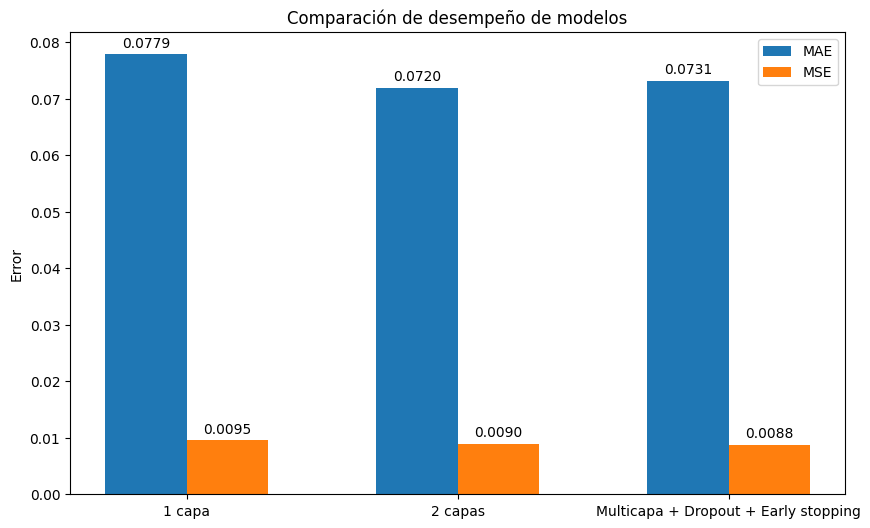

In [32]:
# Celda 4
modelos = ['1 capa',
           '2 capas',
           'Multicapa + Dropout + Early stopping']

# Métricas
mae = [mae_1, mae_2, mae_3]
mse = [mse_1, mse_2, mse_3]

# Posiciones
x = np.arange(len(modelos))

# Ancho barras
width = 0.3

#Figura
fig, ax = plt.subplots(figsize=(10,6))
bars1 = ax.bar(x - width/2, mae, width, label='MAE')
bars2 = ax.bar(x + width/2, mse, width, label='MSE')

ax.set_title('Comparación de desempeño de modelos')
ax.set_ylabel('Error')

ax.set_xticks(x)
ax.set_xticklabels(modelos)

ax.legend()

# Etiquetas sobre barras
for bar in bars1:
    height = bar.get_height()
    ax.annotate(f'{height:.4f}',
                xy=(bar.get_x() + bar.get_width()/2, height),
                xytext=(0,3),
                textcoords="offset points",
                ha='center',
                va='bottom')

for bar in bars2:
    height = bar.get_height()
    ax.annotate(f'{height:.4f}',
                xy=(bar.get_x() + bar.get_width()/2, height),
                xytext=(0,3),
                textcoords="offset points",
                ha='center',
                va='bottom')

plt.show()

La comparación de resultados muestra que los modelos multicapa obtuvieron un mejor desempeño que la red neuronal de una sola capa.

La red neuronal de dos capas logró el menor MAE, indicando una mejor precisión promedio en las predicciones de probabilidad de admisión. Por otro lado, el modelo multicapa con Dropout y EarlyStopping obtuvo el menor MSE, lo cual sugiere una mejor capacidad para reducir errores grandes en las predicciones.

La incorporación de capas ocultas permitió capturar relaciones no lineales más complejas entre las variables predictoras y la variable objetivo, mejorando el desempeño frente al modelo más simple.

Asimismo, las técnicas de regularización implementadas en el Punto 3 contribuyeron a estabilizar el entrenamiento y evitar sobreajuste, como puede observarse en la similitud entre las curvas de entrenamiento y validación.

En general, los resultados evidencian que aumentar moderadamente la complejidad de la red neuronal puede mejorar la capacidad predictiva del modelo, siempre que se utilicen técnicas adecuadas de regularización y control del entrenamiento.